In [6]:
from network_module import WeightedNetwork, AbstractNode, Message, visualize_graph
import networkx as nx
from enum import Enum
from typing import Tuple, List

In [7]:
class MessageType(Enum):
    FIND_MWOE = "find_mwoe"
    REPLY_MWOE = "reply_mwoe"
    CHECK = "check"
    CHECK_RESPONSE = "check_response"
    BROADCAST_MWOE = "broadcast_mwoe"
    REQUEST_TO_MERGE = "request_to_merge"
    REJECT_MERGE_REQUEST = "accept_merge_request"
    NEW_FRAGMENT = "new_fragment"


class NodeState(Enum):
    SEARCH = "search"  # broadcasting find MWOE messages in the fragment
    FIND_MWOE = "find_mwoe"  # finding that nodes MWOE by checking with neighbours
    WAIT_FOR_RESPONSE = "wait_for_response"  # convergecast, waiting to forward onto parent MOE of the subtree of the fragment
    BROADCAST_MOE = "broadcast_moe"
    MERGE = (
        "merge"  # sent the convergecast message and ready to move onto the next phase
    )
    WAITING = "waiting"


class EdgeState(Enum):
    BASIC = "basic"
    BRANCH = "branch"
    REJECTED = "rejected"

In [8]:
class GHSNode(AbstractNode):
    def __init__(self, node_id, neighbours):
        super().__init__(node_id, neighbours)
        self.state: NodeState = NodeState.SEARCH
        self.fragment_id: int = self.node_id
        self.leader_id: int = self.node_id
        self.expected_replies: int = 0
        self.parent: int = None
        self.mwoe_candidate: int = None
        self.mwoe: Tuple[int, float] = None
        self.mwoe_candidates: List[int] = []
        self.fragment_mwoe_weight: int = None
        self.merge_candidate: int = (
            None  # this takes the value of the node adjacent to the MWOE of the fragment only if this node is adjacent to the MWOE otherwise it remains none. Will need to clean up however (i.e. old values not good)
        )
        self.merge_requests: List[Message] = []

        self.adjacent_edges = {
            neighbor: {"status": EdgeState.BASIC, "weight": weight}
            for neighbor, weight in self._neighbours.items()
        }

    def _find_mwoe_candidate(self):
        min_weight = float("inf")
        min_neighbour = None

        for neighbour, edge in self.adjacent_edges.items():
            if edge["status"] == EdgeState.BASIC and edge["weight"] < min_weight:
                min_weight = edge["weight"]
                min_neighbour = neighbour

        if min_neighbour is not None:
            # check the minimum weight adjacent edge leaves the fragment
            self.send_message(
                min_neighbour,
                {
                    "request": MessageType.CHECK,
                    "id": self.node_id,
                    "fragment_id": self.fragment_id,
                },
            )
            # print(
            #     f"I node {self.node_id} have sent a CHECK message to {min_neighbour} to see if they're in the same fragment as me. I am in fragment {self.fragment_id}"
            # )
            self.mwoe_candidate = min_neighbour
        else:
            # No candidate edges, set mwoe to None
            self.mwoe = (None, None)
            self.state = NodeState.WAIT_FOR_RESPONSE

    def _flood_new_fragment(self, message: Message) -> None:
        new_fragment_message = {
            "request": MessageType.NEW_FRAGMENT,
            "fragment_id": self.node_id,
            "id": self.node_id,
        }

        # Notify all BRANCH neighbors and the sender
        for neighbour, edge in self.adjacent_edges.items():
            if edge["status"] == EdgeState.BRANCH:
                self.send_message(neighbour, new_fragment_message)

        self.send_message(message.content["id"], new_fragment_message)

        # update node state now they're done merging
        self.state = NodeState.SEARCH

    def compute(self, round_number):
        if self.leader_id == self.node_id and self.state == NodeState.SEARCH:
            self.expected_replies = 0

            has_branch_edges = False
            for neighbor, edge in self.adjacent_edges.items():
                if edge["status"] == EdgeState.BRANCH:
                    self.send_message(
                        neighbor, {"request": MessageType.FIND_MWOE, "id": self.node_id}
                    )
                    self.expected_replies += 1
                    has_branch_edges = True

            # print(
            #     f"I node {self.node_id} am the leader of my fragment and I am broadcasting a message to tell everyone to FIND_MWOE"
            # )

            self.state = NodeState.FIND_MWOE

            if not has_branch_edges:
                # No branch edges, proceed to find own MWOE
                min_weight = float("inf")
                min_neighbour = None

                for neighbour, edge in self.adjacent_edges.items():
                    if edge["weight"] < min_weight:
                        min_weight = edge["weight"]
                        min_neighbour = neighbour

                self.mwoe = (min_neighbour, min_weight)
                self.state = NodeState.WAIT_FOR_RESPONSE
            else:
                self._find_mwoe_candidate()

        if self.leader_id == self.node_id and self.state == NodeState.BROADCAST_MOE:
            for neighbour, edge in self.adjacent_edges.items():
                if edge["status"] == EdgeState.BRANCH:
                    self.send_message(
                        neighbour,
                        {
                            "request": MessageType.BROADCAST_MWOE,
                            "id": self.node_id,
                            "mwoe": self.fragment_mwoe_weight,
                        },
                    )

            self.state = NodeState.MERGE

            # if the leader has the mwoe of the fragment incident to it
            if self.fragment_mwoe_weight == self.mwoe[1]:
                # try to merge on this edge
                self.send_message(
                    self.mwoe[0],
                    {
                        "request": MessageType.REQUEST_TO_MERGE,
                        "id": self.node_id,
                    },
                )
                # print(
                #     f"I node {self.node_id} am sending a request to merge with node {self.mwoe[0]}"
                # )

                self.merge_candidate = self.mwoe[0]

                self.state = NodeState.MERGE
            else:
                self.merge_candidate = None

        while self.message_queue:
            message = self.message_queue.pop(0)
            request = message.content.get("request")

            if request == MessageType.FIND_MWOE:
                sender: int = message.content["id"]
                # print(
                #     f"I node {self.node_id} have been told by node {sender} to find my MWOE"
                # )
                # keep track of parent in the tree so know where to forward convergecast messages to
                self.parent = sender

                # when we come to convergecast we need to make sure all children have returned their values
                self.expected_replies = 0

                # forward find MWOE message to all other neighbours in the tree (i.e. along edges in the MST, branch edges)
                # don't however send the request back to the neighbour
                for neighbour, edge in self.adjacent_edges.items():
                    if edge["status"] == EdgeState.BRANCH and neighbour != sender:
                        self.send_message(
                            neighbour,
                            {"request": MessageType.FIND_MWOE, "id": self.node_id},
                        )
                        self.expected_replies += 1

                        # print(self.adjacent_edges)
                        # print(
                        #     f"I node {self.node_id} am sending a FIND_MWOE request to {neighbour}"
                        # )

                self.state = NodeState.FIND_MWOE

                # there is a situation where the node doesn't have any remaining outgoing edges in which case we just swtich straight to the other phase REPLY_MWOE
                # this is handled in the _find_mwoe_candidate function
                self._find_mwoe_candidate()

            if request == MessageType.CHECK:
                status = message.content["fragment_id"] != self.fragment_id
                self.send_message(
                    message.content["id"],
                    {"request": MessageType.CHECK_RESPONSE, "status": status},
                )

                # edge cannot be in the MST, reject this edge
                if not status:
                    self.adjacent_edges[message.content["id"]][
                        "status"
                    ] = EdgeState.REJECTED

            if request == MessageType.CHECK_RESPONSE:
                # print(
                #     f"I node {self.node_id} have received a CHECK_RESPONSE from node {self.mwoe_candidate} and {'yes' if message.content['status'] else 'no'} they're in a different fragment"
                # )

                if message.content["status"]:
                    self.mwoe = (
                        self.mwoe_candidate,
                        self.adjacent_edges[self.mwoe_candidate]["weight"],
                    )
                    # Completed own search for MWOE now wait for responses from all children
                    self.state = NodeState.WAIT_FOR_RESPONSE

                    # print(
                    #     f"I am node {self.node_id}, I've found my MOE and its to {self.mwoe_candidate} and has weight {self.adjacent_edges[self.mwoe_candidate]["weight"]}"
                    # )
                    # print(
                    #     f"I node {self.node_id} has {self.expected_replies} expected replies"
                    # )
                else:
                    # don't think you can do this below
                    # self.adjacent_edges[self.mwoe_candidate][
                    #     "status"
                    # ] = EdgeState.REJECTED

                    # print(
                    #     f"Message.REJECTED: node {self.node_id} rejected node {self.mwoe_candidate}"
                    # )

                    self._find_mwoe_candidate()

            if request == MessageType.REPLY_MWOE:
                # check there actually is a MWOE that's been sent by child
                if message.content["mwoe"]:
                    self.mwoe_candidates.append(message.content["mwoe"])

                self.expected_replies -= 1

            if request == MessageType.BROADCAST_MWOE:
                sender: int = message.content["id"]

                for neighbour, edge in self.adjacent_edges.items():
                    if edge["status"] == EdgeState.BRANCH and neighbour != sender:
                        self.send_message(
                            neighbour,
                            {
                                "request": MessageType.BROADCAST_MWOE,
                                "mwoe": message.content["mwoe"],
                            },
                        )

                self.state = NodeState.MERGE

                # if the mwoe of the fragment matches that of this specific node, merge with this edge
                if message.content["mwoe"] == self.mwoe[1]:
                    # try to merge on this edge
                    # TODO: will need to handle situation where the merge request is declined or do we? The fragment shouldn't need to find its MWOE again so instead it need to send another request to merge?
                    self.send_message(
                        self.mwoe[0],
                        {
                            "request": MessageType.REQUEST_TO_MERGE,
                            "id": self.node_id,
                        },
                    )

                    # self.adjacent_edges[self.mwoe[0]]["status"] = EdgeState.BRANCH
                    # print(
                    #     f"Broadcast MWOE recieved: I node {self.node_id} am setting node {message.content["id"]} to branch"
                    # )

                    # print(
                    #     f"BROADCAST_MWOE: I node {self.node_id} am sending a request to merge with node {self.mwoe[0]}"
                    # )

                    self.merge_candidate = self.mwoe[0]
                else:
                    self.merge_candidate = None

            if request == MessageType.REQUEST_TO_MERGE:
                # print(
                #     f"I node {self.node_id} have recieved a request to merge from node {message.content["id"]} and I am in state {self.state}"
                # )

                if self.state == NodeState.MERGE:
                    if self.merge_candidate == message.content["id"]:
                        # set the edge as a branch edge as it is definitely the MOE of the other fragment
                        # print(
                        #     f"Request to Merge: I node {self.node_id} am setting node {message.content["id"]} to branch"
                        # )
                        # self.adjacent_edges[message.content["id"]][
                        #     "status"
                        # ] = EdgeState.BRANCH
                        # print(
                        #     f"Myself node {self.node_id} and {message.content["id"]} both want to merge with each other."
                        # )
                        # they're trying to merge over the same edge
                        # select which ever edge has the higher ID as the leader of the new fragment
                        if self.node_id > message.content["id"]:
                            # This node becomes the new leader of the combined fragment with the id of this node
                            # print(
                            #     f"I node {self.node_id} am the new leader of this fragment with ID {self.node_id}"
                            # )
                            self.fragment_id = self.leader_id = self.node_id
                            self._flood_new_fragment(message)

                            self.adjacent_edges[message.content["id"]][
                                "status"
                            ] = EdgeState.BRANCH

                            self.state = NodeState.SEARCH

                    else:
                        self.merge_requests.append(message)
                        # reject the merge request?
                        self.send_message(
                            message.content["id"],
                            {
                                "request": MessageType.REJECT_MERGE_REQUEST,
                                "id": self.node_id,
                            },
                        )
                else:
                    # print(
                    #     f"**** I node {self.node_id} am adding merge request from node {message.content["id"]} to my list of merge requests!"
                    # )
                    self.merge_requests.append(message)

            if request == MessageType.REJECT_MERGE_REQUEST:
                # I've been rejected but this is still my MOE so just sit and wait in merge
                pass

            if request == MessageType.NEW_FRAGMENT:
                sender: int = message.content["id"]

                self.adjacent_edges[sender]["status"] = EdgeState.BRANCH

                # if self.node_id == 1 or self.node_id == 3:
                #     print(
                #         f"I node {self.node_id} have recieved a new fragment message from node {sender}"
                #     )

                # update local state
                print(f"Message content: {message.content}")

                self.fragment_id = message.content["fragment_id"]
                self.leader_id = None

                # pass the new fragment message to all neighbours in the fragment using the branch edges
                for neighbour, edge in self.adjacent_edges.items():
                    if edge["status"] == EdgeState.BRANCH and neighbour != sender:
                        self.send_message(neighbour, message.content)

                # we can now update the nodes state as its finished merging
                self.state = NodeState.SEARCH

        if self.state == NodeState.WAIT_FOR_RESPONSE and self.expected_replies == 0:
            # print(
            #     f"I am node {self.node_id} and I am ready to send my parent {self.parent} my MWOE"
            # )
            candidates = self.mwoe_candidates + [self.mwoe[1]]
            # print(f"I am node {self.node_id}, my candidates are {candidates}")
            min_weight = min(candidates)

            self.mwoe_candidates.clear()

            if self.fragment_id != self.node_id:
                self.send_message(
                    self.parent,
                    {"request": MessageType.REPLY_MWOE, "mwoe": min_weight},
                )
            else:
                # print(
                #     f"I am the leader of fragment {self.fragment_id} and the minimum weight outgoing edge of the fragment is {min_weight}"
                # )

                self.fragment_mwoe_weight = min_weight

            self.state = NodeState.BROADCAST_MOE

        # if the node now knows whether its MWOE is the one of interest
        if self.state == NodeState.MERGE:
            # print(
            #     f"I am node {self.node_id} and currently I am looking to merge with node {self.merge_candidate} and my message queue has {len(self.merge_requests)} messages in it"
            # )
            # check the merge request queue and see if there is a merge request corresponding to the MWOE of this fragment (info this node now knows)
            # TODO: this needs to change I believe. Because old requests get lost. Request should only be removed from the message_queue if its been satisfied.
            # Use a list to keep track of unsatisfied requests
            unsatisfied_requests = []

            for merge_request in self.merge_requests:
                if merge_request.content["id"] == self.merge_candidate:
                    # print(
                    #     f"Myself node {self.node_id} and {merge_request.content['id']} both want to merge with each other."
                    # )

                    # Respond and send a new_fragment message if this node has the higher ID
                    if self.node_id > merge_request.content["id"]:
                        self.fragment_id = self.node_id
                        self.leader_id = self.node_id

                        # print(
                        #     f"I node {self.node_id} am the new leader of this fragment with ID {self.node_id}"
                        # )
                        self._flood_new_fragment(message)

                        # print(f"I node {self.node_id} am setting the edge to node {merge_request.content['id']} to be a BRANCH edge")
                        self.adjacent_edges[merge_request.content['id']][
                            "status"
                        ] = EdgeState.BRANCH

                        self.state = NodeState.SEARCH
                else:
                    # Keep unsatisfied requests for later processing
                    unsatisfied_requests.append(merge_request)

                    # Optionally send a rejection message
                    self.send_message(
                        merge_request.content["id"],
                        {
                            "request": MessageType.REJECT_MERGE_REQUEST,
                            "id": self.node_id,
                        },
                    )

            # Update the merge_requests queue with only the unsatisfied requests
            self.merge_requests = unsatisfied_requests

What is a check message and why do we need them? When a node is trying to find its MWOE it will check all of its neighbours where the edge leading to it has Basic status. This means the edge hasn't been rejected and isn't in the tree. There is a situation however, where an edge is not in the tree but goes from a node in the fragment to another node in the fragment. We can concretely determine in this case that the edge cannot be in the MST as clearly there was a time when these two nodes were in different fragments and this edge wasn't chosen to be the MWOE. And now it clearly cannot be in the MST as it would create a cycle. We can therefore reject this edge.

The whole functionality of checking an edge needs to be abstracted out. The functionality takes an edge and just checks that it leaves the fragment.

We need a variable that keeps track of the candidates for MOE of each node. The reason we need to do this is because checking requires a message to be sent and a response to be returned and therefore, this must happen over multiple rounds (i.e. calls of the compute function).





So far leader sends messages to neighbours in tree.
Leader knows to send this because of the node state they're put in.
They start in search phase where they tell their neighbours to search
They then move into a phase where they try to find their MOE
- To find the MOE they need to look at their adjacent edges.
- They only consider basic edges, i.e. edges that are not already in the MST and edges that have not be shown to definitely not be in the MST.
- Of these basic edges they start with the edge of minimum weight
- They check if its in the same fragment as them (if it were then it definitely cannot be an edge in the MST)
- If the edge leads to a different fragment, given it was the minimum weight basic edge it must be the MOE from that node.
Once they've done this they move into a phase where they want to convergecast the minimum weight edge
- To do this they need to wait for all of the nodes they told to search to return their MOE. We keep track of this using a state variable that keeps track of the count of how many responses they've recieved.


There could be a situation where two fragments want to merge over the same edge only that one got to it quicker than the other. And therefore, when one of them recieved the message they didn't realise they'd eventually want to merge with the other fragment. Therefore, we need to sit on this merge request until the node is ready to handle it. You could have a queue of merge requests and then when state changes we look at the merge requests and see if any of them match up (i.e. they choose the same edge to merge over) and if any do then proceed with merging.

Its only a problem when a merge request is recieved but the node who recieved the merge request doesn't yet know whether their MWOE is the one to merge over.
(There is an optimisation there, as the node knows the minimum of its subtree and therefore it could reject if subtree MWOE is of weight less than this edge trying to be merged over).

In [9]:
# # Create an empty graph
# G = nx.Graph()

# # Add nodes
# G.add_nodes_from([1, 2, 3, 4])

# # Add edges with weights
# G.add_edge(1, 2, weight=1.5)
# G.add_edge(1, 3, weight=2.0)
# G.add_edge(2, 3, weight=2.5)
# G.add_edge(2, 4, weight=1.0)
# G.add_edge(3, 4, weight=3.0)

# Create an empty graph
G = nx.Graph()

# Add nodes
G.add_nodes_from([1, 2, 3, 4, 5, 6, 7, 8])

# Add edges with weights
G.add_edge(1, 2, weight=1.5)
G.add_edge(1, 3, weight=2.0)
G.add_edge(2, 3, weight=2.5)
G.add_edge(2, 4, weight=1.0)
G.add_edge(3, 4, weight=3.0)
G.add_edge(3, 5, weight=1.8)
G.add_edge(4, 5, weight=2.2)
G.add_edge(5, 6, weight=1.7)
G.add_edge(6, 7, weight=2.8)
G.add_edge(7, 8, weight=1.3)
G.add_edge(8, 1, weight=2.9)
G.add_edge(5, 8, weight=2.4)
G.add_edge(2, 6, weight=1.9)

In [10]:
network = WeightedNetwork(G, GHSNode)
network.run(20)
print(network)

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Message content: {'request': <MessageType.NEW_FRAGMENT: 'new_fragment'>, 'fragment_id': 4, 'id': 4}
Message content: {'request': <MessageType.NEW_FRAGMENT: 'new_fragment'>, 'fragment_id': 6, 'id': 6}
Message content: {'request': <MessageType.NEW_FRAGMENT: 'new_fragment'>, 'fragment_id': 8, 'id': 8}
-------------------------------------------------------------------------------------------------

KeyError: 5

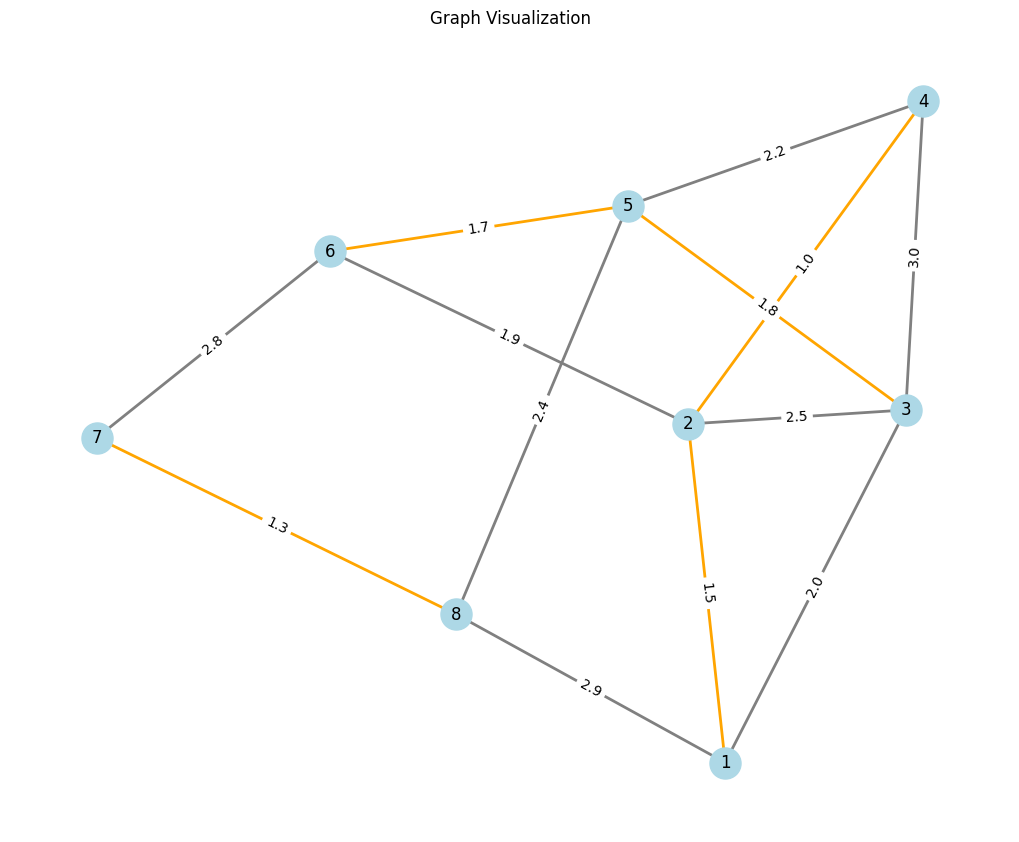

In [ ]:
visualize_graph(G, network.nodes, show_mst_edges=True, seed=123)

If the merge is good why is the new fragment not working?!

The singleton nodes are just going around in circles never merging. These nodes are 1 and 3.

Phase 2: (2,1), (5,3), (8,5)
- Fragment 2 (nodes: 1,2,4)

I'm merging a single node with two other fragments and therefore the ids are interferring. See in example above node 5 (i.e. fragment 6) is merging with both fragment 3 and fragment 8. I assume this cannot happen as multiple node will want to propagate their IDs.

Let's think about this:
- Fragment 8 shouldn't be merging as fragment 6 doesn't want to merge with it. So why is fragment 8 merging?

self.adjacent_edges[sender]["status"] = EdgeState.BRANCH

I think a node is receiving a message from a node it is not adjacent to?

Will have to look at the nodes sending the NEW_FRAGMENT messages and who the messages are sent to.